In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

# Better display formatting
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [7]:
df = pd.read_csv("hospital_readmissions.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [8]:
print("First Five Rows")
display(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())


First Five Rows


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no



Dataset Shape
(25000, 17)

Columns
['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures', 'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [10]:
missing = df.isnull().sum().sort_values(ascending=False)

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [11]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [12]:
df = df.drop_duplicates()

print("Duplicates Removed.")

Duplicates Removed.


In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
time_in_hospital,25000.0,4.45332,3.001470,1.0,2.0,4.0,6.0,14.0
n_lab_procedures,25000.0,43.24076,19.818620,1.0,31.0,44.0,57.0,113.0
n_procedures,25000.0,1.35236,1.715179,0.0,0.0,1.0,2.0,6.0
n_medications,25000.0,16.25240,8.060532,1.0,11.0,15.0,20.0,79.0
n_outpatient,25000.0,0.36640,1.195478,0.0,0.0,0.0,0.0,33.0
n_inpatient,25000.0,0.61596,1.177951,0.0,0.0,0.0,1.0,15.0
n_emergency,25000.0,0.18660,0.885873,0.0,0.0,0.0,0.0,64.0


In [14]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print("=" * 50)
    print(col)
    print(df[col].value_counts())
    print()

age
age
[70-80)     6837
[60-70)     5913
[80-90)     4516
[50-60)     4452
[40-50)     2532
[90-100)     750
Name: count, dtype: int64

medical_specialty
medical_specialty
Missing                   12382
InternalMedicine           3565
Other                      2664
Emergency/Trauma           1885
Family/GeneralPractice     1882
Cardiology                 1409
Surgery                    1213
Name: count, dtype: int64

diag_1
diag_1
Circulatory        7824
Other              6498
Respiratory        3680
Digestive          2329
Diabetes           1747
Injury             1666
Musculoskeletal    1252
Missing               4
Name: count, dtype: int64

diag_2
diag_2
Other              9056
Circulatory        8134
Diabetes           2906
Respiratory        2872
Digestive           973
Injury              591
Musculoskeletal     426
Missing              42
Name: count, dtype: int64

diag_3
diag_3
Other              9107
Circulatory        7686
Diabetes           4261
Respiratory        1915


In [15]:
readmission_counts = df["readmitted"].value_counts()

print(readmission_counts)

readmitted
no     13246
yes    11754
Name: count, dtype: int64


In [16]:
readmission_percentage = (
    df["readmitted"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(readmission_percentage)

readmitted
no     52.98
yes    47.02
Name: proportion, dtype: float64


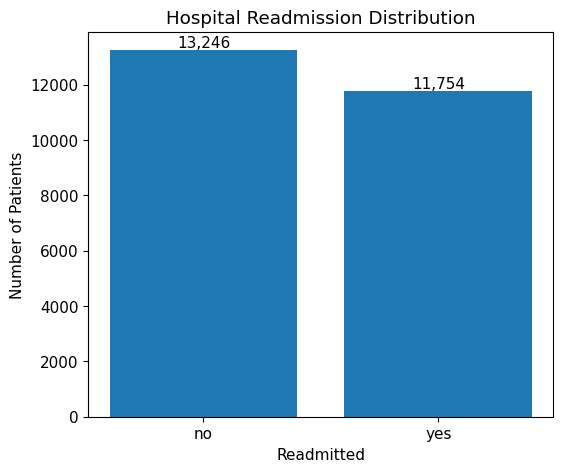

In [17]:
counts = df["readmitted"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    counts.index,
    counts.values
)

plt.title("Hospital Readmission Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")

for i, value in enumerate(counts.values):
    plt.text(i, value, f"{value:,}", ha='center', va='bottom')

plt.show()

In [18]:
readmission_counts = df["readmitted"].value_counts()

print(readmission_counts)

readmitted
no     13246
yes    11754
Name: count, dtype: int64


In [19]:
readmission_percent = (
    df["readmitted"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(readmission_percent)

readmitted
no     52.98
yes    47.02
Name: proportion, dtype: float64


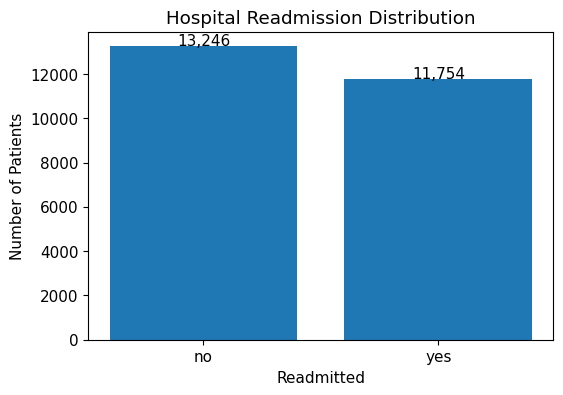

In [20]:
counts = df["readmitted"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    counts.index,
    counts.values
)

plt.title("Hospital Readmission Distribution")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")

for i, value in enumerate(counts.values):
    plt.text(i, value + 50, f"{value:,}", ha="center")

plt.show()

In [21]:
age_readmission = pd.crosstab(
    df["age"],
    df["readmitted"],
    normalize="index"
) * 100

age_readmission = age_readmission.sort_index()

age_readmission.round(2)

readmitted,no,yes
age,,
[40-50),55.49,44.51
[50-60),55.84,44.16
[60-70),53.15,46.85
[70-80),51.21,48.79
[80-90),50.42,49.58
[90-100),57.87,42.13


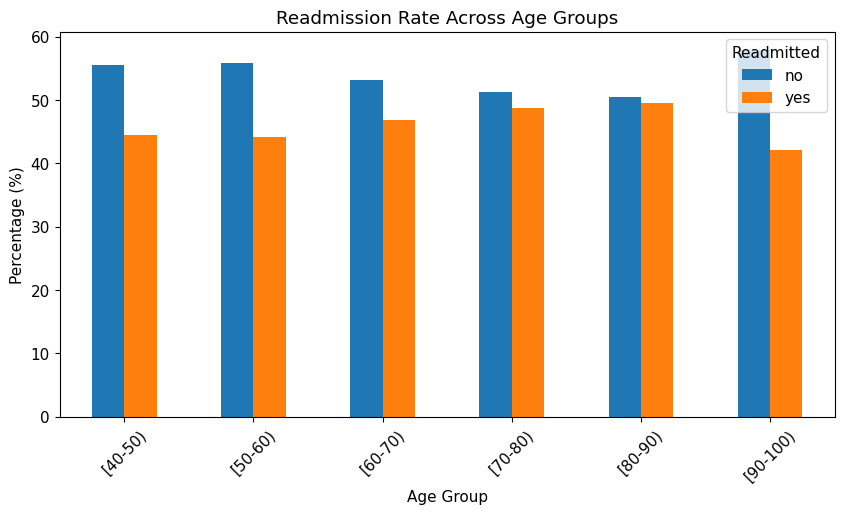

In [22]:
age_readmission.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Readmission Rate Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.legend(title="Readmitted")

plt.xticks(rotation=45)

plt.show()

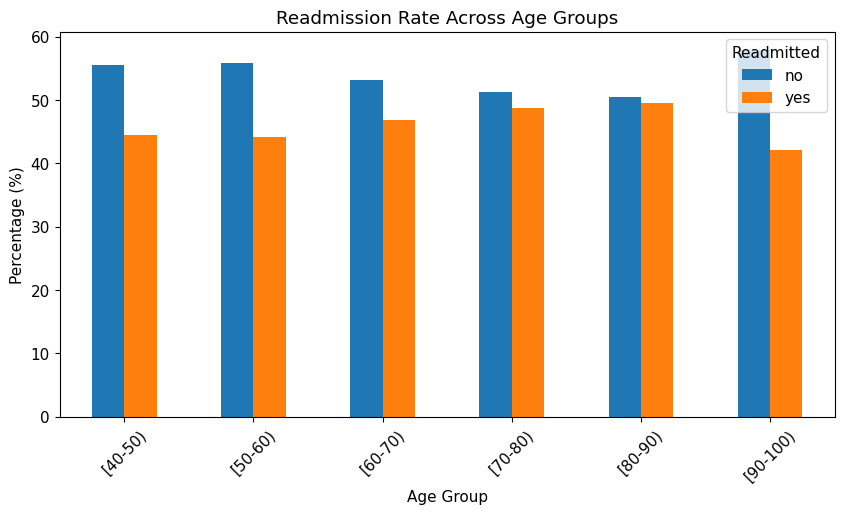

In [23]:
age_readmission.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Readmission Rate Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.legend(title="Readmitted")

plt.xticks(rotation=45)

plt.show()


In [24]:
hospital_days = (
    df.groupby("readmitted")["time_in_hospital"]
      .agg(["count","mean","median","min","max"])
)

hospital_days.round(2)

,count,mean,median,min,max
readmitted,,,,,
no,13246,4.33,4.0,1,14
yes,11754,4.59,4.0,1,14


/tmp/ipykernel_2730/3091831474.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


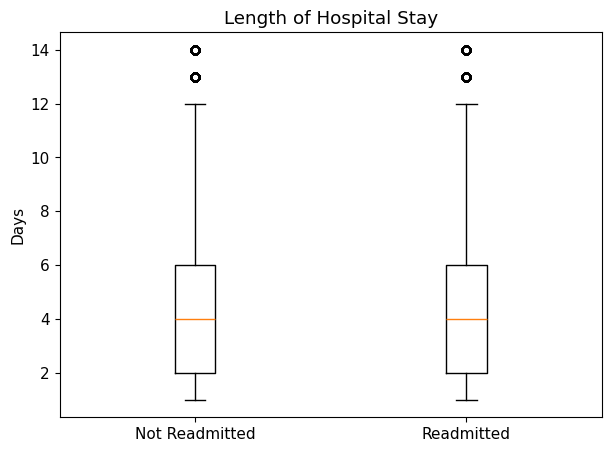

In [25]:
yes = df[df["readmitted"]=="yes"]["time_in_hospital"]
no = df[df["readmitted"]=="no"]["time_in_hospital"]

plt.figure(figsize=(7,5))

plt.boxplot(
    [no, yes],
    labels=["Not Readmitted","Readmitted"]
)

plt.title("Length of Hospital Stay")

plt.ylabel("Days")

plt.show()

/tmp/ipykernel_2730/3091831474.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


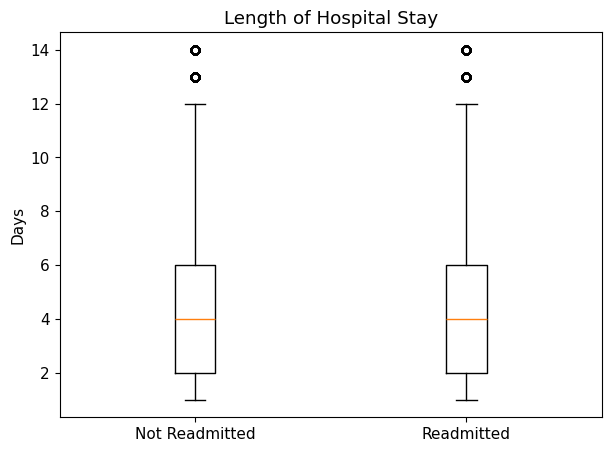

In [26]:
yes = df[df["readmitted"]=="yes"]["time_in_hospital"]
no = df[df["readmitted"]=="no"]["time_in_hospital"]

plt.figure(figsize=(7,5))

plt.boxplot(
    [no, yes],
    labels=["Not Readmitted","Readmitted"]
)

plt.title("Length of Hospital Stay")

plt.ylabel("Days")

plt.show()

/tmp/ipykernel_2730/694409633.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


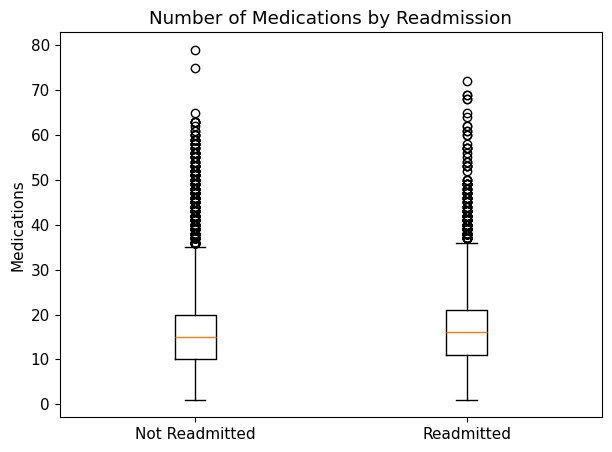

In [27]:
yes = df[df["readmitted"]=="yes"]["n_medications"]
no = df[df["readmitted"]=="no"]["n_medications"]

plt.figure(figsize=(7,5))

plt.boxplot(
    [no, yes],
    labels=["Not Readmitted","Readmitted"]
)

plt.title("Number of Medications by Readmission")

plt.ylabel("Medications")

plt.show()

In [28]:
visit_columns = [
    "n_outpatient",
    "n_inpatient",
    "n_emergency"
]

df.groupby("readmitted")[visit_columns].mean().round(2)

,n_outpatient,n_inpatient,n_emergency
readmitted,,,
no,0.26,0.38,0.11
yes,0.49,0.88,0.27


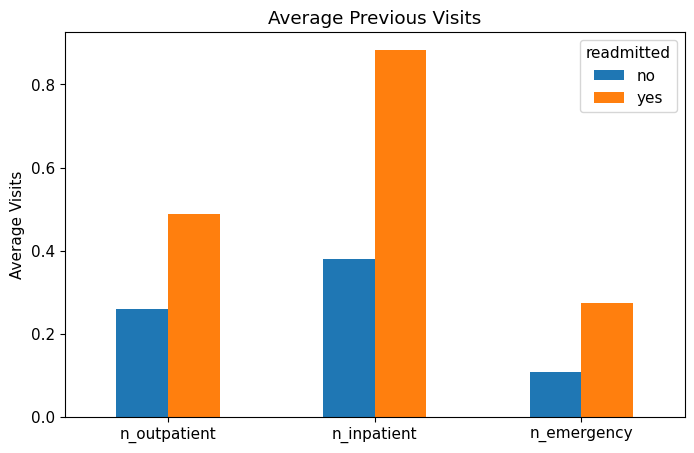

In [29]:
visit_means = df.groupby("readmitted")[visit_columns].mean()

visit_means.T.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Previous Visits")

plt.ylabel("Average Visits")

plt.xticks(rotation=0)

plt.show()

In [30]:
specialty = pd.crosstab(
    df["medical_specialty"],
    df["readmitted"],
    normalize="index"
) * 100

specialty = specialty.sort_values(
    by="yes",
    ascending=False
)

specialty.round(2)

readmitted,no,yes
medical_specialty,,
Family/GeneralPractice,50.48,49.52
Emergency/Trauma,50.61,49.39
Missing,51.09,48.91
Cardiology,55.00,45.00
InternalMedicine,55.23,44.77
Other,58.52,41.48
Surgery,58.78,41.22


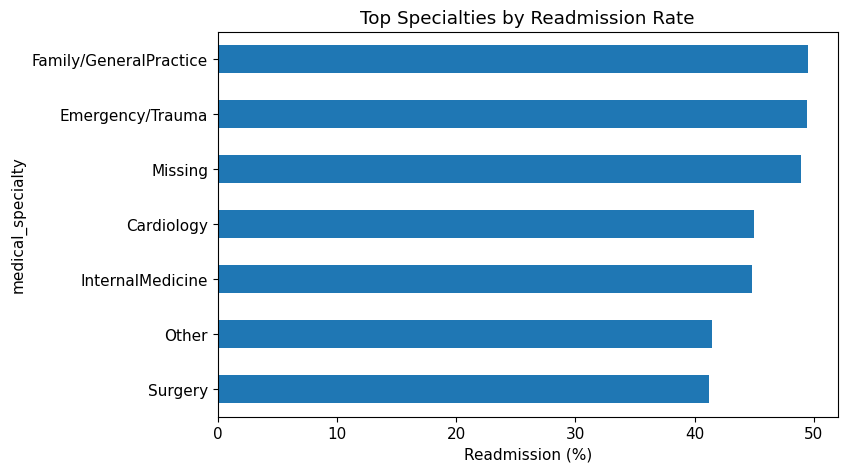

In [31]:
top_specialty = specialty.head(10)

top_specialty["yes"].plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Specialties by Readmission Rate")

plt.xlabel("Readmission (%)")

plt.gca().invert_yaxis()

plt.show()

In [32]:
diagnosis = (
    df[df["readmitted"]=="yes"]["diag_1"]
      .value_counts()
)

diagnosis


,count
diag_1,
Circulatory,3750
Other,2932
Respiratory,1806
Digestive,1105
Diabetes,937
Injury,727
Musculoskeletal,495
Missing,2


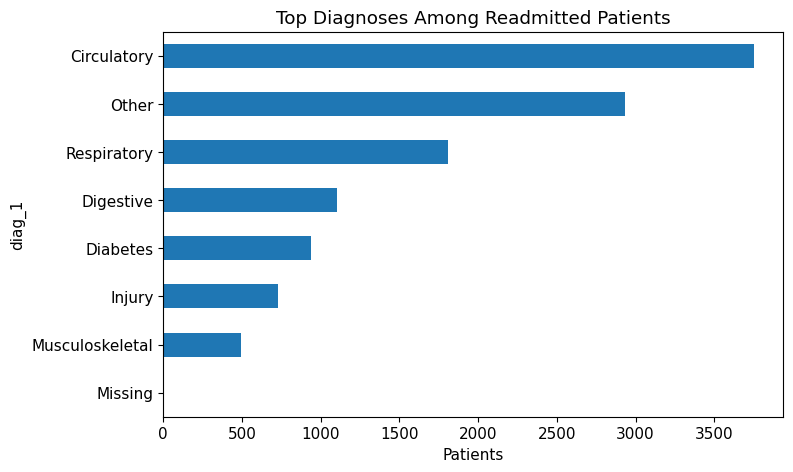

In [33]:
diagnosis.head(10).plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Top Diagnoses Among Readmitted Patients")

plt.xlabel("Patients")

plt.gca().invert_yaxis()

plt.show()

In [34]:
med_change = pd.crosstab(
    df["change"],
    df["readmitted"],
    normalize="index"
) * 100

med_change.round(2)

readmitted,no,yes
change,,
no,54.98,45.02
yes,50.65,49.35


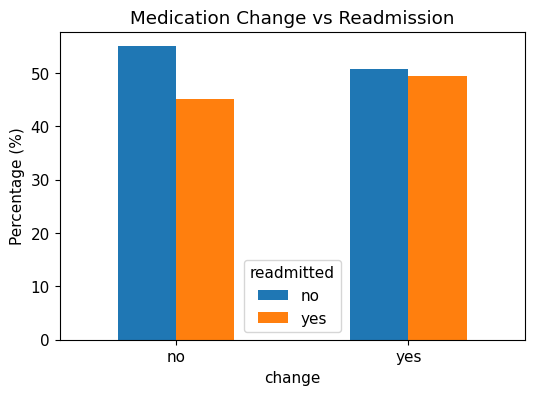

In [35]:
med_change.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Medication Change vs Readmission")

plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.show()

In [36]:
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr().round(2)

corr

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
time_in_hospital,1.00,0.33,0.18,0.45,-0.01,0.08,-0.01
n_lab_procedures,0.33,1.00,0.05,0.27,-0.00,0.04,-0.00
n_procedures,0.18,0.05,1.00,0.37,-0.03,-0.07,-0.04
n_medications,0.45,0.27,0.37,1.00,0.04,0.07,0.01
n_outpatient,-0.01,-0.00,-0.03,0.04,1.00,0.13,0.10
n_inpatient,0.08,0.04,-0.07,0.07,0.13,1.00,0.22
n_emergency,-0.01,-0.00,-0.04,0.01,0.10,0.22,1.00


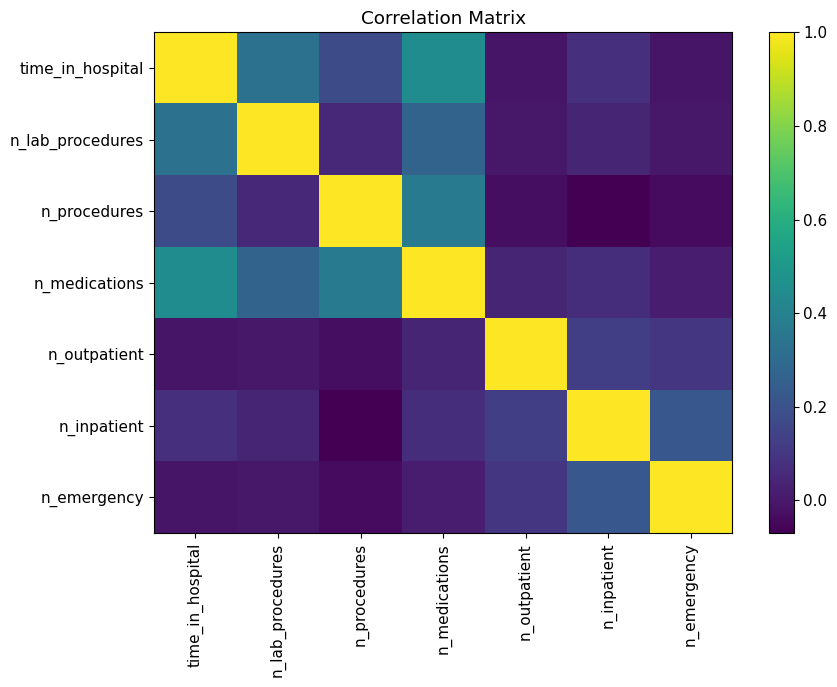

In [37]:
plt.figure(figsize=(9,7))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [38]:
total_patients = len(df)

readmitted = (df["readmitted"] == "yes").sum()

rate = (readmitted / total_patients) * 100

print(f"Total Patients: {total_patients:,}")
print(f"Readmitted Patients: {readmitted:,}")
print(f"Readmission Rate: {rate:.2f}%")

Total Patients: 25,000
Readmitted Patients: 11,754
Readmission Rate: 47.02%


In [39]:
age_table = pd.crosstab(
    df["age"],
    df["readmitted"],
    normalize="index"
) * 100

age_table = age_table.sort_values("yes", ascending=False)

age_table.round(2)

readmitted,no,yes
age,,
[80-90),50.42,49.58
[70-80),51.21,48.79
[60-70),53.15,46.85
[40-50),55.49,44.51
[50-60),55.84,44.16
[90-100),57.87,42.13


In [40]:
df.groupby("readmitted")["time_in_hospital"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
no,13246.0,4.33,3.0,1.0,2.0,4.0,6.0,14.0
yes,11754.0,4.59,3.0,1.0,2.0,4.0,6.0,14.0


In [41]:
df.groupby("readmitted")["n_medications"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
readmitted,,,,,,,,
no,13246.0,15.97,8.45,1.0,10.0,15.0,20.0,79.0
yes,11754.0,16.57,7.58,1.0,11.0,16.0,21.0,72.0


In [42]:
visit_summary = (
    df.groupby("readmitted")[
        ["n_outpatient", "n_inpatient", "n_emergency"]
    ]
    .mean()
    .round(2)
)

visit_summary

,n_outpatient,n_inpatient,n_emergency
readmitted,,,
no,0.26,0.38,0.11
yes,0.49,0.88,0.27


In [43]:
specialty = (
    pd.crosstab(
        df["medical_specialty"],
        df["readmitted"],
        normalize="index"
    ) * 100
)

specialty.sort_values("yes", ascending=False).head(10).round(2)

readmitted,no,yes
medical_specialty,,
Family/GeneralPractice,50.48,49.52
Emergency/Trauma,50.61,49.39
Missing,51.09,48.91
Cardiology,55.00,45.00
InternalMedicine,55.23,44.77
Other,58.52,41.48
Surgery,58.78,41.22


In [44]:
summary = pd.DataFrame({
    "Metric": [
        "Total Patients",
        "Readmitted Patients",
        "Readmission Rate (%)",
        "Average Hospital Stay (Readmitted)",
        "Average Hospital Stay (Not Readmitted)",
        "Average Medications (Readmitted)",
        "Average Medications (Not Readmitted)"
    ],
    "Value": [
        len(df),
        (df["readmitted"] == "yes").sum(),
        round(
            ((df["readmitted"] == "yes").mean()) * 100,
            2
        ),
        round(
            df[df["readmitted"] == "yes"]["time_in_hospital"].mean(),
            2
        ),
        round(
            df[df["readmitted"] == "no"]["time_in_hospital"].mean(),
            2
        ),
        round(
            df[df["readmitted"] == "yes"]["n_medications"].mean(),
            2
        ),
        round(
            df[df["readmitted"] == "no"]["n_medications"].mean(),
            2
        )
    ]
})

summary

,Metric,Value
0,Total Patients,25000.00
1,Readmitted Patients,11754.00
2,Readmission Rate (%),47.02
3,Average Hospital Stay (Readmitted),4.59
4,Average Hospital Stay (Not Readmitted),4.33
5,Average Medications (Readmitted),16.57
6,Average Medications (Not Readmitted),15.97
